In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama

In [2]:
llm = ChatOllama(
    model="qwen3:4b",
    temperature=0.6
)

In [3]:
class State(TypedDict):
    topic: str
    characters: str
    settings: str
    premises: str
    story_intro: str

In [4]:
# Nodes
def generate_characters(state: State):
    """Generate character descriptions"""
    msg = llm.invoke(f"Create two character names and brief traits for a story about {state['topic']}")
    return {"characters": msg.content}

def generate_setting(state: State):
    """Generate a story setting"""
    msg = llm.invoke(f"Describe a vivid setting for a story about {state['topic']}")
    return {"settings": msg.content}

def generate_premise(state: State):
    """Generate a story premise"""
    msg = llm.invoke(f"Write a one-sentence plot premise for a story about {state['topic']}")
    return {"premises": msg.content}

def combine_elements(state: State):
    """Combine characters, setting, and premise into an intro"""
    msg = llm.invoke(
        f"Write a short story introduction using these elements:\n"
        f"Characters: {state['characters']}\n"
        f"Setting: {state['settings']}\n"
        f"Premise: {state['premises']}"
    )
    return {"story_intro": msg.content}

In [6]:
# Build the graph
graph = StateGraph(State)
graph.add_node("character", generate_characters)
graph.add_node("setting", generate_setting)
graph.add_node("premise", generate_premise)
graph.add_node("combine", combine_elements)

graph.add_edge(START, "character")
graph.add_edge(START, "setting")
graph.add_edge(START, "premise")
graph.add_edge("character", "combine")
graph.add_edge("setting", "combine")
graph.add_edge("premise", "combine")
graph.add_edge("combine", END)


compiled_graph = graph.compile()

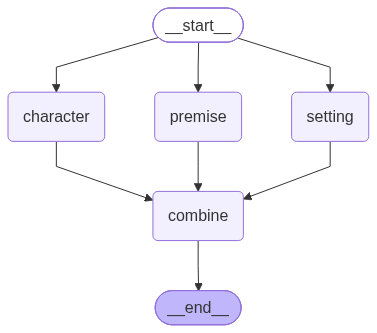

In [7]:
compiled_graph

In [8]:
state = {"topic": "time travel"}
result = compiled_graph.invoke(state)
print(result["story_intro"])

Here’s a tight, immersive introduction (198 words) that weaves your characters, setting, and premise into a single electric moment—**no clichés, maximum emotional punch**:

---

Kai stumbled into the Chronos Library, the scent of wet stone and burnt honey hitting him like a physical blow. His vision fractured—*shifting light*—a flicker of silver threads in the air, then the smell of rain on pavement, the ache of a child’s scraped knee. *Lena*. His sister. *Always Lena*.  

He saw it: a car crash on a rain-slicked road in 2024, but the memory was wrong. *Too* wrong. His hands shook as he reached for the First Page—its glassy cover humming with the weight of all timelines. The moment he touched it, the library screamed.  

*“You’re late,”* Elara’s voice cut through the silence, precise as a snapped twig. Her silver scars—thin threads of fading light on her skin—unraveled like smoke. *“The moment you broke the timeline, it’s now 2.7 seconds before the collapse.”*  

Kai’s breath hitched. 